/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


✅ PaddleOCR imported successfully.
✅ Schema validator 'validate_extraction' imported successfully.

--- Initializing PaddleOCR ---
✅ PaddleOCR engine initialized (CPU).

--- Loading LLM Model and Tokenizer ---
Loading tokenizer for 'HuggingFaceH4/zephyr-7b-beta'...
✅ Tokenizer loaded.
Loading model 'HuggingFaceH4/zephyr-7b-beta'...


Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

✅ Model loaded successfully on device(s) via device_map='auto'. Primary device: cuda:0
Model loading took 72.58 seconds.

--- Loading Image and Schema: 'income_salary_slip' ---
Schema path: schemas/income_salary_slip.json
✅ Successfully loaded schema: income_salary_slip.json
Image path: /teamspace/studios/this_studio/standard_salary_slip_format.png
✅ Image loaded for reference: standard_salary_slip_format.png


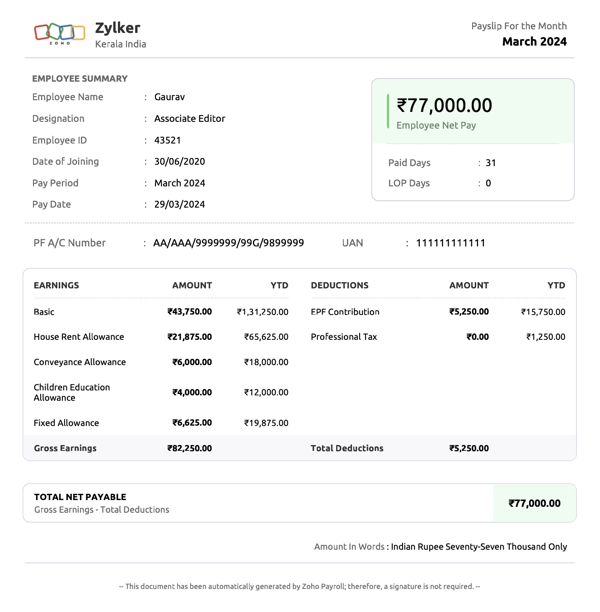


--- Performing OCR with PaddleOCR ---
   Running OCR on: standard_salary_slip_format.png
   OCR finished in 7.27 seconds.
✅ OCR successful. Extracted 65 lines of text.

--- Raw OCR Text ---


```text
Zylker Payslip For the Month ZOHO Kerala India March 2024 EMPLOYEE SUMMARY Employee Name : Gaurav 77,000.00 Designation
: Associate Editor Employee Net Pay Employee ID : 43521 Date of Joining : 30/06/2020 Paid Days : 31 Pay Period : March
2024 LOP Days : 0 Pay Date : 29/03/2024 PF A/C Number : AA/AAA/9999999/99G/9899999 UAN : 111111111111 EARNINGS AMOUNT
YTD DEDUCTIONS AMOUNT YTD Basic 43,750.00 1,31,250.00 EPF Contribution 5,250.00 15,750.00 House Rent Allowance 21,875.00
65,625.00 Professional Tax 0.00 1,250.00 Conveyance Allowance 6,000.00 18,000.00 Children Education Allowance 4,000.00
12,000.00 Fixed Allowance 6,625.00 19,875.00 Gross Earnings 82,250.00 Total Deductions 5,250.00 TOTAL NET PAYABLE
<77,000.00 Gross Earnings - Total Deductions Amount In Words : Indian Rupee Seventy-Seven Thousand Only. -- This
document has been automatically generated by Zoho Payroll; therefore, a signature is not required. -
```

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



--- Generating Comprehensive Prompt for Text Structuring ---
✅ Prompt generated for 'income_salary_slip' using OCR text.

--- Structuring OCR Text using LLM ---
Timestamp: 2025-04-24 19:25:16, Max New Tokens: 1536
   Processing text prompt for LLM...
   Generating structured response from 'HuggingFaceH4/zephyr-7b-beta'...
   Decoding response...
   LLM structuring took 44.75 seconds.

--- Raw LLM Output (Attempted JSON) ---


```json
{
  "employeeSummary": {
    "employeeName": "Gaurav",
    "designation": "Associate Editor",
    "employeeID": "43521",
    "dateOfJoining": "30/06/2020",
    "payPeriod": "March 2024",
    "payDate": "29/03/2024",
    "pfAccountNumber": "AA/AAA/9999999/99G/9899999",
    "uan": "111111111111",
    "paidDays": 31,
    "lopDays": 0
  },
  "earnings": {
    "basic": {
      "amount": "43,750.00",
      "ytd": "1,31,250.00"
    },
    "houseRentAllowance": {
      "amount": "21,875.00",
      "ytd": "65,625.00"
    },
    "conveyanceAllowance": {
      "amount": "6,000.00",
      "ytd": "18,000.00"
    },
    "childrenEducationAllowance": {
      "amount": "4,000.00",
      "ytd": "12,000.00"
    },
    "fixedAllowance": {
      "amount": "6,625.00",
      "ytd": "19,875.00"
    }
  },
  "deductions": {
    "epfContribution": {
      "amount": "5,250.00",
      "ytd": "15,750.00"
    },
    "professionalTax": {
      "amount": "0.00",
      "ytd": "1,250.00"
    }
  },
  "grossEarnings": "82,250.00",
  "totalDeductions": "5,250.00",
  "netPay": "<77,000.00>",
  "netPayInWords": "Gross Earnings - Total Deductions\nAmount In Words : Indian Rupee Seventy-Seven Thousand Only."
}
```


--- Parsing Extracted JSON ---
   Found JSON block by locating first '{' and last '}'.
   Attempting to parse JSON (first 200 chars): {
  "employeeSummary": {
    "employeeName": "Gaurav",
    "designation": "Associate Editor",
    "employeeID": "43521",
    "dateOfJoining": "30/06/2020",
    "payPeriod": "March 2024",
    "payDate"...
✅ Successfully parsed JSON from response.

--- Post-Processing Extracted Data ---
   Post-processing 'dateOfJoining': '30/06/2020' -> '2020-06-30'
   Post-processing 'payDate': '29/03/2024' -> '2024-03-29'
   Post-processing 'employeeSummary': '{'employeeName': 'Gaurav', 'designation': 'Associate Editor', 'employeeID': '43521', 'dateOfJoining': '30/06/2020', 'payPeriod': 'March 2024', 'payDate': '29/03/2024', 'pfAccountNumber': 'AA/AAA/9999999/99G/9899999', 'uan': '111111111111', 'paidDays': 31, 'lopDays': 0}' -> '{'employeeName': 'Gaurav', 'designation': 'Associate Editor', 'employeeID': '43521', 'dateOfJoining': '2020-06-30', 'payPeriod': 'March 2024'

**✅ PASSED** - ✅ Schema Validated: Extracted data conforms to the 'income_salary_slip' schema (income_salary_slip.json).


--- Script Finished ---


In [1]:
# --- IMPORTS ---
import os
import json
import time
import re
import textwrap
from pathlib import Path
from typing import Dict, Any, Tuple, Optional, List

# --- PaddleOCR Import ---
try:
    from paddleocr import PaddleOCR
    paddleocr_imported = True
    print("✅ PaddleOCR imported successfully.")
except ImportError as e:
    print(f"⚠️ Warning: Could not import 'paddleocr'. Please install it (`pip install paddleocr paddlepaddle`). Error: {e}")
    paddleocr_imported = False
    # Define a dummy class if import fails to avoid NameErrors later
    class PaddleOCR:
        def __init__(self, **kwargs): pass
        def ocr(self, img_path, cls=True):
            print("ERROR: PaddleOCR not imported. Cannot perform OCR.")
            return [[],] # Return format similar to paddleocr on empty/error

# --- Other Imports ---
from PIL import Image # For image loading/display
import torch
# Use standard transformers for text processing LLM
from transformers import AutoTokenizer, AutoModelForCausalLM
import IPython

# --- Display Setup ---
try:
    shell = IPython.get_ipython().__class__.__name__
    if shell == 'ZMQInteractiveShell':
        from IPython.display import display, Markdown
    else:
        # Fallback for non-notebook environments
        display = print
        def Markdown(text): print(text) # Simple print for Markdown
except NameError:
    # Fallback if IPython is not available at all
    display = print
    def Markdown(text): print(text) # Simple print for Markdown
except Exception as e:
    print(f"IPython display setup warning: {e}")
    display = print
    def Markdown(text): print(text)

# --- Schema Validator Import ---
try:
    from src.schema_validator import validate_extraction
    validator_imported = True
    print("✅ Schema validator 'validate_extraction' imported successfully.")
except ImportError as e:
    print(f"⚠️ Warning: Could not import 'validate_extraction' from 'src.schema_validator'. Validation will be skipped. Create src/schema_validator.py or adjust import. Error: {e}")
    validator_imported = False
    def validate_extraction(data: Any, document_type: str) -> Tuple[bool, str]:
        return False, "Validation skipped: Validator module not found or failed to import."
except Exception as e:
    print(f"⚠️ Warning: An unexpected error occurred during validator import: {e}")
    validator_imported = False
    def validate_extraction(data: Any, document_type: str) -> Tuple[bool, str]:
        return False, f"Validation skipped: Error during validator import ({e})."

# --- CONFIGURATION ---
DOC_TYPE = "income_salary_slip"
# *** IMPORTANT: Update this path to your actual image file ***
IMAGE_PATH = "/teamspace/studios/this_studio/standard_salary_slip_format.png" # <--- CHANGE THIS
# --- End Configuration Edit --- #
if IMAGE_PATH == "/path/to/your/salary_slip_image.png":
     print("⚠️ WARNING: IMAGE_PATH is set to the default placeholder. Please update it.")
elif not Path(IMAGE_PATH).exists():
     print(f"⚠️ WARNING: IMAGE_PATH '{IMAGE_PATH}' does not exist. Please verify the path.")

SCHEMAS_DIR = Path("schemas")
MAX_TOKENS = 1536 # Max tokens for the LLM structuring the OCR text
HF_TOKEN = None # Set your Hugging Face token string here if needed (e.g., "hf_...")
MODEL_ID = "HuggingFaceH4/zephyr-7b-beta" # LLM for structuring the OCR text

# --- HELPER FUNCTIONS ---

def load_schema(schema_path: Path) -> Optional[Dict[str, Any]]:
    """Loads a JSON schema file."""
    if not schema_path.is_file():
        print(f"❌ Schema file not found: {schema_path}")
        return None
    try:
        with open(schema_path, 'r', encoding='utf-8') as f:
            schema = json.load(f)
        print(f"✅ Successfully loaded schema: {schema_path.name}")
        return schema
    except json.JSONDecodeError as e:
        print(f"❌ Invalid JSON in schema file {schema_path}: {e}")
        return None
    except Exception as e:
        print(f"❌ Failed to read schema file {schema_path}: {e}")
        return None

# --- CORRECTED describe_property function (Fix for TypeError) ---
def describe_property(prop_name: str, prop_schema: dict, required_fields: List[str], indent_level=0) -> str:
    """Recursively describes a schema property for the prompt."""
    description = ""
    indent = "  " * indent_level
    constraints = []
    # Get description safely, default to empty string
    prop_description_raw = prop_schema.get("description", "")
    # *** FIX: Ensure description is treated as a string ***
    prop_description = str(prop_description_raw) if prop_description_raw is not None else ""

    if prop_description:
        # Use the guaranteed string version
        description += f"{indent}# {prop_description}\n"

    prop_type = prop_schema.get("type")
    # Schema types are typically strings or lists of strings
    if prop_type: constraints.append(f"type: {prop_type}")

    if prop_type == "string":
        if "minLength" in prop_schema: constraints.append(f"min_len: {prop_schema['minLength']}")
        if "maxLength" in prop_schema: constraints.append(f"max_len: {prop_schema['maxLength']}")
        if "pattern" in prop_schema: constraints.append(f"pattern: `{prop_schema['pattern']}`")
        # f-string handles list representation for enum
        if "enum" in prop_schema: constraints.append(f"enum: {prop_schema['enum']}")
        if "format" in prop_schema: constraints.append(f"format: {prop_schema['format']}")
    elif prop_type in ["number", "integer"]:
        if "minimum" in prop_schema: constraints.append(f"min: {prop_schema['minimum']}")
        if "maximum" in prop_schema: constraints.append(f"max: {prop_schema['maximum']}")
    elif prop_type == "array":
        if "minItems" in prop_schema: constraints.append(f"min_items: {prop_schema['minItems']}")
        if "maxItems" in prop_schema: constraints.append(f"max_items: {prop_schema['maxItems']}")

    constraint_str = ", ".join(constraints) if constraints else "no specific constraints"
    required_marker = "**(required)**" if prop_name in required_fields else "(optional)"
    description += f"{indent}- `{prop_name}` {required_marker} ({constraint_str})\n"

    if prop_type == "object" and "properties" in prop_schema:
        nested_required = prop_schema.get("required", [])
        # Get object's own description
        obj_description_raw = prop_schema.get("description", "")
        # *** FIX: Ensure description is treated as a string ***
        obj_description = str(obj_description_raw) if obj_description_raw is not None else ""
        # Check if we already added this description above (if it was the top-level property description)
        # This avoids duplicate description comments for the object property itself.
        if obj_description and obj_description not in description:
             description += f"{indent}  # {obj_description}\n"
        description += f"{indent}  Properties:\n"
        for nested_name, nested_schema in prop_schema["properties"].items():
            # Recursive call result should be string, safe to concatenate
            description += describe_property(nested_name, nested_schema, nested_required, indent_level + 1)

    elif prop_type == "array" and "items" in prop_schema:
        item_schema = prop_schema["items"]
        item_type = item_schema.get("type", "any")
        # Description for the array itself
        arr_description_raw = prop_schema.get("description", "")
        # *** FIX: Ensure description is treated as a string ***
        arr_description = str(arr_description_raw) if arr_description_raw is not None else ""
        # Avoid duplicate description if it was already added for the array property
        if arr_description and arr_description not in description:
            description += f"{indent}  # {arr_description}\n"
        description += f"{indent}  Each item should be type '{item_type}'.\n"

        if item_type == "object" and "properties" in item_schema:
             item_obj_description_raw = item_schema.get("description", "Each item object contains:")
             # *** FIX: Ensure description is treated as a string ***
             item_obj_description = str(item_obj_description_raw) if item_obj_description_raw is not None else ""
             description += f"{indent}  # {item_obj_description}\n"
             nested_required = item_schema.get("required", [])
             for item_prop_name, item_prop_schema in item_schema["properties"].items():
                 # Recursive call result should be string, safe to concatenate
                 description += describe_property(item_prop_name, item_prop_schema, nested_required, indent_level + 2)
        # Optionally handle descriptions for arrays of simple types if needed

    return description
# --- End CORRECTED describe_property function ---

# --- CORRECTED generate_comprehensive_prompt function (Fix for TypeError) ---
def generate_comprehensive_prompt(schema: dict, doc_type: str, ocr_text: str) -> str:
    """Generates ONE detailed prompt for the LLM to structure OCR text."""
    if not schema:
        raise ValueError("Schema cannot be None for prompt generation.")
    doc_type_name = doc_type.replace('_', ' ').title()
    schema_title = schema.get("title", f"'{doc_type_name}' document")
    # *** FIX: Ensure schema description is treated as a string ***
    schema_description_raw = schema.get("description", "")
    schema_description = str(schema_description_raw) if schema_description_raw is not None else ""

    prompt_intro_parts = [
        f"You are an expert document processing assistant specialized in extracting structured information from **TEXT** with **maximum accuracy**, specifically focusing on **{doc_type_name}** documents.",
        f"Analyze the following text meticulously. It was extracted via OCR from a {doc_type_name}.",
        f"Your task is to extract information based *only* on this text and structure it precisely according to the following JSON schema definition for a **{schema_title}**.",
    ]
    if schema_description:
        # Use guaranteed string
        prompt_intro_parts.append(f"Schema description: {schema_description}")

    prompt_intro_parts.extend([
        f"Extract values for the fields below directly from the provided text. Adhere **strictly** to all constraints:",
        f"  - **Data Types** (string, number, boolean, array, object).",
        f"  - **Required Fields** (marked **(required)**) - these MUST be included in the JSON.",
        f"  - **String Constraints** (length, patterns like IDs/Dates/PAN, enums, format). **CRITICAL: Match patterns exactly.** Convert dates to 'YYYY-MM-DD' if possible based on text.",
        f"  - **Numeric/Array Constraints** (min/max values or items).",
        f"  - **Nested Structures**: Follow the object/array structure precisely."
    ])
    prompt_intro = "\n".join(prompt_intro_parts) + "\n"

    field_descriptions = "\n--- JSON Schema Structure & Fields ---\n"
    top_level_properties = schema.get("properties", {})
    top_level_required = schema.get("required", [])
    if not top_level_properties:
        raise ValueError("Schema missing top-level 'properties'.")

    # Add top-level schema description if not already in intro
    if schema_description and "Schema description:" not in prompt_intro:
        # Use guaranteed string
        field_descriptions += f"# {schema_description}\n"

    for prop_name, prop_schema in top_level_properties.items():
        # Calls the corrected describe_property function
        field_descriptions += describe_property(prop_name, prop_schema, top_level_required, 0)

    ocr_text_section = f"\n--- OCR Text Content ---\n```text\n{ocr_text}\n```\n--- End OCR Text Content ---"

    prompt_outro = (
        "\n--- Output Instructions ---\n"
        "1.  **Output ONLY the JSON:** Your *entire* response MUST be a single, valid JSON object. Start with `{` and end with `}`. NO explanations, apologies, summaries, or markdown backticks (```json ... ```) surrounding the JSON object itself."
        "2.  **Strict Schema Adherence:** The output JSON MUST conform strictly to the structure, types, and constraints defined in the schema above, using only information present in the OCR text.",
        "3.  **Required Fields:** Ensure all fields marked **(required)** are present in the output JSON. If a required field's value absolutely cannot be found in the text, use JSON `null`, but only if the schema allows `null` for that field type (check `type: ['string', 'null']`). If `null` is not allowed, you must infer a plausible value if possible or indicate the failure clearly if extraction is impossible (though try to avoid this by finding *something* in the text).",
        "4.  **Optional Fields:** If an optional field's value is not found in the text, **OMIT the field entirely** from the JSON output. DO NOT use `null` for missing optional fields unless the schema explicitly allows `null` (e.g., `type: ['string', 'null']`).",
        "5.  **Accuracy Paramount:** Extract values accurately. Double-check numbers, IDs (like PAN), names, and dates against the OCR text. Ensure correct formatting (e.g., `YYYY-MM-DD` for dates if specified).",
        "6.  **No Extra Information:** Do not add fields not defined in the schema. Do not include comments within the JSON unless the schema specifies it (which is rare)."
        "7.  **Currency/Units:** Extract numeric values for currency fields, generally omitting symbols like '₹' or '$' unless the schema pattern requires them. Check the specific field description."
        "8.  **Boolean Fields**: Interpret textual cues (like 'Yes'/'No', 'True'/'False', presence/absence of a checkmark description) to determine boolean `true` or `false` values."
    )
    # Ensure all parts are strings before concatenating
    return str(prompt_intro) + str(field_descriptions) + str(ocr_text_section) + str(prompt_outro)
# --- End CORRECTED generate_comprehensive_prompt function ---

def post_process_extracted_data(data: Dict[str, Any], schema: Dict[str, Any]) -> Dict[str, Any]:
    """Applies rule-based cleaning to extracted data *before* validation."""
    processed_data = {}
    if not isinstance(data, dict):
        print(f"⚠️ Post-processing warning: Input data is not a dictionary ({type(data)}), returning as is.")
        return data
    if not schema or 'properties' not in schema:
        print(f"⚠️ Post-processing warning: Schema invalid or missing properties, returning data as is.")
        return data

    schema_props = schema.get("properties", {})

    for key, value in data.items():
        prop_schema = schema_props.get(key, {})
        # Can be string or list like ['string', 'null']
        prop_type = prop_schema.get("type")
        prop_pattern = prop_schema.get("pattern")
        original_value = value # Keep track for logging

        # --- Apply Specific Cleaning Rules ---
        cleaned_value = value

        # Handle null values explicitly - keep them if they are present
        if cleaned_value is None:
            processed_data[key] = None
            continue

        # Generic String Cleanup (applied first)
        if isinstance(cleaned_value, str):
            cleaned_value = cleaned_value.strip()
            # Optional: Remove excessive internal whitespace
            # cleaned_value = re.sub(r'\s+', ' ', cleaned_value).strip()

        # Rule for PAN Number (adjust key if schema differs)
        if key == "PAN Number" and isinstance(cleaned_value, str):
            cleaned_value = re.sub(r'[^A-Z0-9]', '', cleaned_value.upper())

        # Rule for Currency fields (example: Net Salary)
        elif key == "Net Salary" and isinstance(cleaned_value, str):
             cleaned_value_numeric = re.sub(r'[₹$,\s]', '', cleaned_value)
             if re.match(r'^\d+(\.\d+)?$', cleaned_value_numeric):
                 cleaned_value = cleaned_value_numeric
             else:
                 cleaned_value = cleaned_value.lstrip('₹$€ ').strip()

        # Rule for Date Fields (example: Assuming 'date' format in schema -> YYYY-MM-DD)
        elif isinstance(cleaned_value, str) and prop_schema.get("format") == "date":
            match_dmy_slash = re.match(r'(\d{1,2})/(\d{1,2})/(\d{4})', cleaned_value)
            match_dmy_dash = re.match(r'(\d{1,2})-(\d{1,2})-(\d{4})', cleaned_value)
            if match_dmy_slash:
                d, m, y = match_dmy_slash.groups()
                cleaned_value = f"{y}-{int(m):02d}-{int(d):02d}"
            elif match_dmy_dash:
                d, m, y = match_dmy_dash.groups()
                cleaned_value = f"{y}-{int(m):02d}-{int(d):02d}"

        # Recursive processing for nested objects and arrays
        elif isinstance(cleaned_value, dict) and prop_type == "object":
            nested_schema = prop_schema
             # Recurse
            cleaned_value = post_process_extracted_data(cleaned_value, nested_schema)

        elif isinstance(cleaned_value, list) and prop_type == "array":
            item_schema = prop_schema.get("items")
            if item_schema and item_schema.get("type") == "object":
                 cleaned_value = [post_process_extracted_data(item, item_schema) if isinstance(item, dict) else item for item in cleaned_value]
            elif item_schema and item_schema.get("type") == "string":
                 cleaned_value = [item.strip() if isinstance(item, str) else item for item in cleaned_value]

        # Log if changed
        if cleaned_value != original_value:
             print(f"   Post-processing '{key}': '{original_value}' -> '{cleaned_value}'")

        processed_data[key] = cleaned_value

    return processed_data

# --- Main Execution ---

# --- Initialize PaddleOCR ---
print("\n--- Initializing PaddleOCR ---")
ocr_engine = None
ocr_error = None
if paddleocr_imported:
    try:
        ocr_engine = PaddleOCR(use_angle_cls=True, lang='en', use_gpu=False, show_log=False)
        print("✅ PaddleOCR engine initialized (CPU).")
    except Exception as e:
        print(f"❌ Error initializing PaddleOCR: {e}")
        ocr_error = f"PaddleOCR Initialization Error: {e}"
        paddleocr_imported = False
else:
    ocr_error = "OCR Skipped: PaddleOCR library not imported or failed to import."
    print(f"⚠️ {ocr_error}")


# --- LOAD LLM MODEL & TOKENIZER ---
print("\n--- Loading LLM Model and Tokenizer ---")
model = None
tokenizer = None
llm_load_error = None
try:
    print(f"Loading tokenizer for '{MODEL_ID}'...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=HF_TOKEN)
    print("✅ Tokenizer loaded.")

    print(f"Loading model '{MODEL_ID}'...")
    model_load_start_time = time.time()
    try:
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_ID,
            torch_dtype=torch.float16,
            device_map="auto", # Automatically distribute model layers
            token=HF_TOKEN
        )
        try:
             model_device = next(model.parameters()).device
             print(f"✅ Model loaded successfully on device(s) via device_map='auto'. Primary device: {model_device}")
        except Exception:
             print(f"✅ Model loaded successfully via device_map='auto'. (Could not determine exact device mapping easily).")

    except ImportError:
        print("⚠️ 'accelerate' library not found (pip install accelerate). Falling back to manual device placement.")
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"   Placing model on: {device}")
        model = AutoModelForCausalLM.from_pretrained(
            MODEL_ID,
            torch_dtype=torch.float16 if device.type == 'cuda' else torch.float32, # Use float32 on CPU
            token=HF_TOKEN,
            low_cpu_mem_usage=True # Helps when loading large models
        ).to(device)
        print(f"✅ Model loaded successfully on: {model.device}")
    except Exception as e_load:
         print(f"❌ Error loading model '{MODEL_ID}': {e_load}")
         # Make model loading critical
         raise RuntimeError(f"Failed to load model: {e_load}")

    print(f"Model loading took {time.time() - model_load_start_time:.2f} seconds.")

except Exception as e:
    llm_load_error = f"LLM/Tokenizer loading failed: {e}"
    print(f"❌❌ FATAL ERROR: {llm_load_error}")
    # Stop execution if model loading fails
    model = None
    tokenizer = None


# --- LOAD IMAGE & SCHEMA ---
print(f"\n--- Loading Image and Schema: '{DOC_TYPE}' ---")
schema = None
image_path_obj = Path(IMAGE_PATH)
schema_path = SCHEMAS_DIR / f"{DOC_TYPE}.json"
print(f"Schema path: {schema_path}")
schema = load_schema(schema_path) # Handles errors internally, returns None on failure

print(f"Image path: {image_path_obj}")
image_load_error = None
img_for_display = None
if not image_path_obj.is_file():
    image_load_error = f"Image file not found: {IMAGE_PATH}"
    print(f"❌ {image_load_error}")
else:
    try:
        img_for_display = Image.open(image_path_obj).convert("RGB")
        print(f"✅ Image loaded for reference: {image_path_obj.name}")
        max_display_width = 600
        w, h = img_for_display.size
        if w > 0:
             display_h = int(h * (max_display_width / w))
             try:
                 if callable(display):
                    display(img_for_display.resize((max_display_width, display_h)))
                 else:
                    print("   (Skipping image display preview: display function not available)")
             except Exception as display_err:
                 print(f"   (Could not display image preview inline: {display_err})")
        else:
            print("   (Skipping image display: Invalid image width)")
    except Exception as e:
         image_load_error = f"Could not load image for display: {e}"
         print(f"⚠️ Warning: {image_load_error}")


# --- PERFORM OCR ---
print("\n--- Performing OCR with PaddleOCR ---")
ocr_results: Optional[List] = None
ocr_text_content: str = ""
# Inherit error from init if it failed
if ocr_error:
    print(f"   Skipping OCR due to initialization error: {ocr_error}")
elif not paddleocr_imported:
     ocr_error = "OCR Skipped: PaddleOCR library not available."
     print(f"❌ {ocr_error}")
elif not ocr_engine:
    ocr_error = "OCR Skipped: Engine not initialized (unknown reason)."
    print(f"❌ {ocr_error}")
elif image_load_error or not image_path_obj.is_file():
    ocr_error = f"OCR Skipped: Image not loaded or not found ({image_load_error or 'File not found'})."
    print(f"❌ {ocr_error}")
else:
    ocr_start_time = time.time()
    try:
        print(f"   Running OCR on: {image_path_obj.name}")
        ocr_raw_output = ocr_engine.ocr(str(image_path_obj), cls=True)
        elapsed_ocr_time = time.time() - ocr_start_time
        print(f"   OCR finished in {elapsed_ocr_time:.2f} seconds.")

        if ocr_raw_output and isinstance(ocr_raw_output, list) and len(ocr_raw_output) > 0:
             ocr_results = ocr_raw_output[0]
             if ocr_results and isinstance(ocr_results, list):
                 lines = [line[1][0] for line in ocr_results if line and len(line) > 1 and line[1] and len(line[1]) > 0]
                 ocr_text_content = "\n".join(lines)
                 print(f"✅ OCR successful. Extracted {len(lines)} lines of text.")
                 print("\n--- Raw OCR Text ---")
                 display(Markdown(f"```text\n{textwrap.fill(ocr_text_content, width=120)}\n```"))
             else:
                  print("   ⚠️ OCR ran but returned no text results within the expected structure.")
                  ocr_error = "OCR Error: No text detected or unexpected result format."
                  ocr_text_content = ""
        else:
             print("   ⚠️ OCR returned empty or invalid results.")
             ocr_error = "OCR Error: Empty or invalid output from PaddleOCR engine."
             ocr_text_content = ""

    except Exception as e:
        print(f"❌ Error during PaddleOCR processing: {e}")
        ocr_error = f"OCR Processing Error: {e}"
        ocr_results = None
        ocr_text_content = ""


# --- GENERATE COMPREHENSIVE PROMPT (using corrected functions) ---
print("\n--- Generating Comprehensive Prompt for Text Structuring ---")
prompt = None
comprehensive_prompt_text = None
prompt_error = None
# Check for blocking errors before attempting prompt generation
if llm_load_error:
    prompt_error = f"Skipped: LLM loading failed: {llm_load_error}"
    print(f"   ⚠️ {prompt_error}")
elif ocr_error or not ocr_text_content:
    prompt_error = f"Skipped: No OCR text available. Reason: {ocr_error or 'No text extracted'}"
    print(f"   ⚠️ {prompt_error}")
elif not schema:
    prompt_error = "Skipped: Schema not loaded successfully."
    print(f"   ❌ {prompt_error}")
else:
    # Proceed only if prerequisites are met
    try:
        # Uses the corrected generate_comprehensive_prompt which calls the corrected describe_property
        comprehensive_prompt_text = generate_comprehensive_prompt(schema, DOC_TYPE, ocr_text_content)
        # Format for Zephyr/chat models
        prompt = f"<|user|>\n{comprehensive_prompt_text}\n<|assistant|>\n"
        print(f"✅ Prompt generated for '{DOC_TYPE}' using OCR text.")
        # Optional: Display prompt snippet for debugging
        # print("\n--- Generated Prompt Snippet ---")
        # display(Markdown(f"```\n{textwrap.fill(prompt[:1000], width=120)}...\n```"))
    except Exception as e:
        # Catch potential errors during prompt generation itself now
        prompt_error = f"Error generating prompt: {e}"
        print(f"❌ {prompt_error}")
        # Uncomment below to see the full traceback for the prompt error
        # import traceback
        # print(traceback.format_exc())


# --- PERFORM EXTRACTION (Structure OCR Text using LLM) ---
print("\n--- Structuring OCR Text using LLM ---")
parsed_json: Optional[Dict[str, Any]] = None
processed_json: Optional[Dict[str, Any]] = None
raw_output_text = ""
# Consolidate all critical errors up to this point
llm_error = ocr_error or llm_load_error or prompt_error

if not llm_error and model and tokenizer and prompt:
    extraction_start_time = time.time()
    print(f"Timestamp: {time.strftime('%Y-%m-%d %H:%M:%S')}, Max New Tokens: {MAX_TOKENS}")
    try:
        print("   Processing text prompt for LLM...")
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(model.device)

        print(f"   Generating structured response from '{MODEL_ID}'...")
        with torch.inference_mode():
             generate_ids = model.generate(
                **inputs,
                max_new_tokens=MAX_TOKENS,
                do_sample=False, # Crucial for predictable JSON
                temperature=0.0, # Use 0.0 for greedy decoding
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id # Ensure proper stopping
            )
        print("   Decoding response...")
        # Decode only newly generated tokens
        output_ids = generate_ids[0][inputs['input_ids'].shape[1]:]
        raw_output_text = tokenizer.decode(output_ids, skip_special_tokens=True).strip()

        elapsed_time = time.time() - extraction_start_time
        print(f"   LLM structuring took {elapsed_time:.2f} seconds.")
        print("\n--- Raw LLM Output (Attempted JSON) ---")
        # Display assuming output should be JSON-like
        display(Markdown(f"```json\n{raw_output_text}\n```"))

    except Exception as e:
         llm_error = f"LLM Generation/Structuring Error: {e}"
         print(f"❌❌ FATAL ERROR during LLM text structuring: {e}")
         raw_output_text = f"ERROR_GENERATION: {llm_error}"

# --- Log reasons for skipping ---
elif llm_error:
     print(f"   Skipping LLM structuring due to previous error: {llm_error}")
elif not model:
     llm_error = "LLM Structuring Skipped: Model not loaded."
     print(f"❌ {llm_error}")
elif not tokenizer:
     llm_error = "LLM Structuring Skipped: Tokenizer not loaded."
     print(f"❌ {llm_error}")
elif not prompt:
     llm_error = "LLM Structuring Skipped: Prompt not generated."
     print(f"❌ {llm_error}")


# --- Parse JSON ---
print("\n--- Parsing Extracted JSON ---")
json_parsing_error = None
if raw_output_text and not llm_error:
    json_string = None
    try:
        # Attempt to extract JSON robustly
        match_md = re.search(r"```json\s*(\{.*?\})\s*```", raw_output_text, re.DOTALL | re.IGNORECASE)
        if match_md:
            json_string = match_md.group(1)
            print("   Found JSON block inside markdown ```json ... ```.")
        else:
            first_brace = raw_output_text.find('{')
            last_brace = raw_output_text.rfind('}')
            if first_brace != -1 and last_brace != -1 and last_brace > first_brace:
                json_string = raw_output_text[first_brace : last_brace + 1]
                print("   Found JSON block by locating first '{' and last '}'.")
            else:
                 print("   ⚠️ Could not locate a JSON block ({...}) in the raw output.")
                 json_parsing_error = "Parsing Error: No JSON object braces found."

        if json_string:
            print(f"   Attempting to parse JSON (first 200 chars): {json_string[:200]}...")
            parsed_json = json.loads(json_string)
            print("✅ Successfully parsed JSON from response.")
        elif not json_parsing_error: # If we didn't find braces but didn't set error yet
             json_parsing_error = "Parsing Error: No JSON content identified."

    except json.JSONDecodeError as e:
        json_parsing_error = f"JSONDecodeError: {e}"
        print(f"   ❌ {json_parsing_error}")
        print(f"      Content Snippet (up to 500 chars): {json_string[:500] if json_string else raw_output_text[:500]}...")
    except Exception as e:
        json_parsing_error = f"Unexpected parsing error: {e}"
        print(f"   ❌ {json_parsing_error}")

elif llm_error:
    print(f"   Skipping JSON parsing due to earlier error: {llm_error}")
    json_parsing_error = llm_error # Carry the error forward
else:
    json_parsing_error = "Parsing Error: Raw LLM output was empty."
    print(f"   Skipping JSON parsing: {json_parsing_error}")

# Update the main error flag if parsing failed and no prior error existed
if json_parsing_error and not llm_error:
    llm_error = json_parsing_error


# --- Post-Process JSON ---
print("\n--- Post-Processing Extracted Data ---")
post_processing_error = None
if parsed_json and schema:
    try:
        # Ensure the function definition is available above
        processed_json = post_process_extracted_data(parsed_json, schema)
        print("✅ Post-processing complete.")
    except NameError: # Should not happen if defined above
        post_processing_error = "Post-processing Error: Function 'post_process_extracted_data' not defined."
        print(f"   ❌ {post_processing_error}")
        if not llm_error: llm_error = post_processing_error
        processed_json = parsed_json # Fallback
    except Exception as e:
        post_processing_error = f"Post-processing Error: {e}"
        print(f"   ❌ Error during post-processing: {e}")
        if not llm_error: llm_error = post_processing_error
        processed_json = parsed_json # Fallback
elif llm_error:
     print(f"   Skipping post-processing due to prior error: {llm_error}")
elif not parsed_json:
     print("   Skipping post-processing: No JSON was parsed successfully.")
elif not schema:
     print("   Skipping post-processing: Schema was not loaded.")
     if not llm_error: llm_error = "Post-processing Error: Schema not loaded."


# --- DISPLAY FINAL PROCESSED RESULT ---
print("\n--- Final Processed & Cleaned Result ---")
if processed_json:
    print(json.dumps(processed_json, indent=2, ensure_ascii=False))
elif parsed_json and not processed_json:
    print("Displaying parsed (but not post-processed) JSON:")
    print(json.dumps(parsed_json, indent=2, ensure_ascii=False))
elif llm_error:
    print(f"No valid JSON available. Final Error Status: {llm_error}")
    if raw_output_text:
        print(f"\n--- Raw LLM Output (before parsing attempt) ---")
        display(Markdown(f"```\n{raw_output_text}\n```"))
    else:
        print("(Raw LLM output was empty or not generated)")
else:
    print("No JSON was successfully extracted or processed.")
    if raw_output_text:
        print(f"\n--- Raw LLM Output (before parsing attempt) ---")
        display(Markdown(f"```\n{raw_output_text}\n```"))


# --- VALIDATE FINAL RESULT ---
print("\n--- Validating Result Against Schema ---")
validation_result_msg = "Validation not performed."
is_valid = False
# Prioritize validating processed data, fall back to parsed
data_to_validate = processed_json if processed_json is not None else parsed_json

if not validator_imported:
    validation_result_msg = "Skipped: Validator module not imported."
elif not schema_path or not schema: # Check if schema was loaded
    validation_result_msg = "Skipped: Schema not available or path undefined."
elif data_to_validate is None:
    validation_result_msg = f"Skipped: No valid JSON data available for validation."
    # Append the root cause if validation is skipped due to prior errors
    if llm_error: validation_result_msg += f" Final Error: {llm_error}"
elif not isinstance(data_to_validate, dict):
     validation_result_msg = f"Skipped: Data to validate is not a dictionary ({type(data_to_validate).__name__})."
     if llm_error: validation_result_msg += f" Final Error: {llm_error}"
else:
    print(f"Validating {'processed' if processed_json is not None else 'parsed'} JSON against '{DOC_TYPE}' schema...")
    try:
        # Ensure the validator function is available
        is_valid, validation_result_msg = validate_extraction(data_to_validate, DOC_TYPE)
        print("Validation check complete.")
        if is_valid:
            # Validator should return a success message
            print(f"✅ {validation_result_msg}")
        else:
            # Display the detailed error message(s) from the validator
            print(f"❌ Validation Failed.")
            display(Markdown(f"**Validation Errors:**\n```\n{validation_result_msg}\n```"))
            # Set a summary message, the details are in the Markdown output
            validation_result_msg = "Schema validation failed (see details above)."
    except NameError: # If validate_extraction wasn't imported/defined
         validation_result_msg = "❌ Validation Error: 'validate_extraction' function not found (check import)."
         print(validation_result_msg)
         is_valid = False
    except Exception as e:
        validation_result_msg = f"❌ Unexpected validation error: {e}"
        print(validation_result_msg)
        is_valid = False # Ensure invalid on exception

final_status = "✅ PASSED" if is_valid else "❌ FAILED / SKIPPED"
print("\n📋 Final Schema Validation Status:")
display(Markdown(f"**{final_status}** - {validation_result_msg}"))
# If validation failed or skipped, and we had an earlier error, show the root cause
if not is_valid and llm_error:
    display(Markdown(f"Root Cause Error impacting result: {llm_error}"))


print("\n--- Script Finished ---")

In [2]:
import torch
print(torch.cuda.memory_summary())

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |      0 B   |
|       from small pool |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |